In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# change plotly style
import plotly.io as pio
pio.templates.default = "presentation"

c:\Users\ahmad\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Plot Sigmoid Function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

px.line(x=x, y=y, title="Sigmoid Function", width=800, height=400)


# Iris Dataset

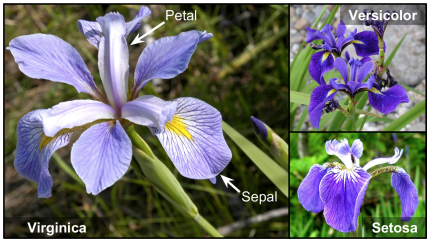

In [3]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [5]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [6]:
iris.target

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int32

In [7]:
iris.target.value_counts()

0    50
1    50
2    50
Name: target, dtype: int64

In [8]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [9]:
iris.target_names[iris.target]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

# Binary Classification with One Feature

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [11]:
# plot the decision boundary

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)  # reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)

fig = px.line(x=X_new[:, 0], y=y_proba[:, 1], title="Sigmoid Function", width=800, height=400, labels={"x": "petal width (cm)", "y": "Probability"})
# add the decision boundary
fig.add_vline(x=X_new[y_proba[:, 1] >= 0.5][0, 0], line_width=3, line_dash="dash", line_color="red")
fig.add_hline(y=0.5, line_width=3, line_dash="dash", line_color="red")
fig.show()


In [12]:
log_reg.coef_[0][0]

3.8363771518292133

In [13]:
log_reg.intercept_[0]

-6.3329301342346636

In [14]:
X_new[y_proba[:, 1] >= 0.5][0, 0]

1.6516516516516517

In [15]:
z = log_reg.intercept_[0] + 1.65165 * log_reg.coef_[0][0] 
y_proba = sigmoid(z)

print("z: ", z)
print("Probability: ", y_proba)

z:  0.003422188584057295
Probability:  0.5008555463110459


In [16]:
log_reg.decision_function([[1.65165]])

array([0.00342219])

In [17]:
log_reg.predict_proba([[1.65165]])

array([[0.49914445, 0.50085555]])

In [18]:
log_reg.predict_proba([[1.65165]])[0,1]

0.5008555463110459

# Binary Classification with Two Features

In [19]:
# Take Two Features (petal width and petal length)
X = iris.data[["petal width (cm)", "petal length (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [20]:
# plot the decision boundary

X0, X1 = np.meshgrid(
    np.linspace(0, 3, 500).reshape(-1, 1),
    np.linspace(0, 8, 200).reshape(-1, 1),
)

X_new = np.c_[X0.ravel(), X1.ravel()]

y_proba = log_reg.predict_proba(X_new)

px.scatter(x=X_new[:, 0], y=X_new[:, 1], color=y_proba[:, 1], width=800, height=400, labels={"x": "petal width (cm)", "y": "petal length (cm)", "color": "Probability"})


In [21]:
log_reg.predict_proba([[1.65165, 4.5]])

array([[0.72742803, 0.27257197]])

In [22]:
z = log_reg.intercept_[0] + 1.65165 * log_reg.coef_[0][0] + 4.5 * log_reg.coef_[0][1]
z

-0.9816123599367028

In [23]:
log_reg.decision_function([[1.65165, 4.5]])

array([-0.98161236])

In [24]:
log_reg.score(X_train, y_train)

0.9553571428571429

In [25]:
log_reg.score(X_test, y_test)

1.0

# Multiclass Classification

In [26]:
X = iris.data.values
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [27]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [28]:
log_reg.predict_proba(X_test[[0]])

array([[0.0039815 , 0.82217309, 0.17384541]])

In [29]:
pred = np.argmax(log_reg.predict_proba(X_test[[0]]), axis=1)
pred

array([1], dtype=int64)

In [30]:
pred = log_reg.predict(X_test[[0]])
pred

array([1])

In [31]:
pred_name = iris.target_names[pred]
pred_name

array(['versicolor'], dtype='<U10')

In [32]:
log_reg = LogisticRegression(random_state=42, max_iter=1000, multi_class="multinomial", solver="lbfgs")
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [33]:
%timeit log_reg = LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr', solver='liblinear').fit(X_train, y_train)

425 µs ± 4.77 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [34]:
%timeit log_reg = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial', solver='lbfgs').fit(X_train, y_train)

15.5 ms ± 257 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [35]:
log_reg.score(X_train, y_train)

0.9642857142857143

In [36]:
log_reg.score(X_test, y_test)

1.0

# Regularization

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
]

log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', multi_class='ovr')

grid_search = GridSearchCV(log_reg, param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(max_iter=1000, multi_class='ovr',
                                          random_state=42, solver='liblinear'),
             param_grid=[{'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                          'penalty': ['l1', 'l2']}])

In [38]:
# best hyperparameters
grid_search.best_params_

{'C': 10, 'penalty': 'l2'}

In [39]:
log_reg = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear', multi_class='ovr', C=10, penalty='l2')
log_reg.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=1000, multi_class='ovr', random_state=42,
                   solver='liblinear')

In [40]:
log_reg.score(X_train, y_train)

0.9732142857142857

In [41]:
log_reg.score(X_test, y_test)

1.0

# Classification Metrics

In [106]:
X = iris.data.values[:55, :]
y = iris.target[:55]

In [107]:
y.value_counts()

0    50
1     5
Name: target, dtype: int64

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [109]:
y_train.value_counts(), y_test.value_counts()

(0    37
 1     4
 Name: target, dtype: int64,
 0    13
 1     1
 Name: target, dtype: int64)

In [110]:
# Most Frequent Class
y_train.mode()[0], y_test.mode()[0]

(0, 0)

In [111]:
Train_Accuracy = y_train.value_counts()[y_train.mode()[0]] / len(y_train)
Test_Accuracy = y_test.value_counts()[y_test.mode()[0]] / len(y_test)

print(" Train Accuracy: ", Train_Accuracy)
print(" Test Accuracy: ", Test_Accuracy)

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


In [112]:
# Dummy Classifier
from sklearn.base import BaseEstimator
class DummyClassifier(BaseEstimator):
    def fit(self, X, y):
        return self
    def predict(self, X):
        # return the most frequent class
        return np.full((len(X), 1), y_train.mode()[0])

In [113]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score

print(" Train Accuracy: ", accuracy_score(y_train, dummy_clf.predict(X_train)))
print(" Test Accuracy: ", accuracy_score(y_test, y_pred))

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


In [115]:
# Dummy Classifier
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)

y_pred = dummy_clf.predict(X_test)

print(" Train Accuracy: ", accuracy_score(y_train, dummy_clf.predict(X_train)))
print(" Test Accuracy: ", accuracy_score(y_test, y_pred))

 Train Accuracy:  0.9024390243902439
 Test Accuracy:  0.9285714285714286


In [116]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[13,  0],
       [ 1,  0]], dtype=int64)

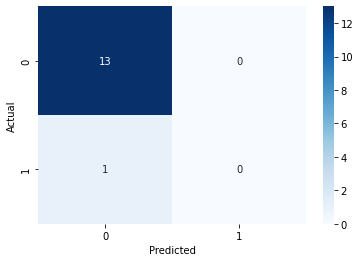

In [117]:
# plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

c:\Users\ahmad\anaconda3\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning:

Function plot_confusion_matrix is deprecated; Function `plot_confusion_matrix` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: ConfusionMatrixDisplay.from_predictions or ConfusionMatrixDisplay.from_estimator.



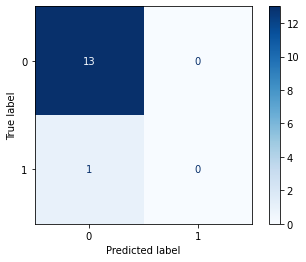

In [118]:
# plot confusion matrix
from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(dummy_clf, X_test, y_test, cmap='Blues')

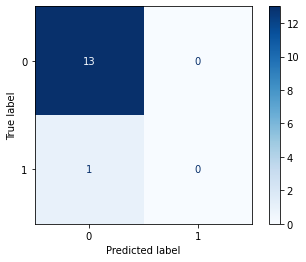

In [119]:
# Confusion Matrix Display
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')

In [125]:
# Precision
from sklearn.metrics import precision_score

print(" Precision: ", precision_score(y_test, y_pred))
print(" Precision_0: ", precision_score(y_test, y_pred, pos_label=0))

 Precision:  0.0
 Precision_0:  0.9285714285714286


c:\Users\ahmad\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



In [126]:
# Recall
from sklearn.metrics import recall_score
print(" Recall: ", recall_score(y_test, y_pred))
print(" Recall_0: ", recall_score(y_test, y_pred, pos_label=0))

 Recall:  0.0
 Recall_0:  1.0


In [127]:
# F1 Score
from sklearn.metrics import f1_score
print(" F1 Score: ", f1_score(y_test, y_pred))
print(" F1 Score_0: ", f1_score(y_test, y_pred, pos_label=0))

 F1 Score:  0.0
 F1 Score_0:  0.962962962962963


In [124]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       0.00      0.00      0.00         1

    accuracy                           0.93        14
   macro avg       0.46      0.50      0.48        14
weighted avg       0.86      0.93      0.89        14

